In [1]:
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(os.path.join('..')))

from src.data_preprocessing import run_preprocessing
from src.indexing import create_vector_store

# Define pathsß
RAW_DATA = "../data/raw/complaints.csv"
PROCESSED_DATA = "../data/processed/filtered_complaints.csv"
VECTOR_STORE_DIR = "../vector_store/faiss_index"

print("Setup complete. Ready to run pipeline.")

/Users/mac/Documents/kaim/rag-complaint-chatbot/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete. Ready to run pipeline.


In [2]:
df_cleaned = run_preprocessing(RAW_DATA, PROCESSED_DATA)

print("\nFirst 5 rows of cleaned data:")
display(df_cleaned[['Product_Group', 'cleaned_narrative']].head())

Loading dataset...
Removed 459718 records without narratives.
Cleaning text narratives...
Saved 445576 records to ../data/processed/filtered_complaints.csv

First 5 rows of cleaned data:


,Product_Group,cleaned_narrative
12237,Credit card,a card was opened under my name by a fraudster...
12532,Savings account,i made the mistake of using my wellsfargo debi...
13280,Credit card,dear cfpb i have a secured credit card with ci...
13506,Credit card,i have a citi rewards cards the credit balance...
13955,Credit card,bi am writing to dispute the following charges...


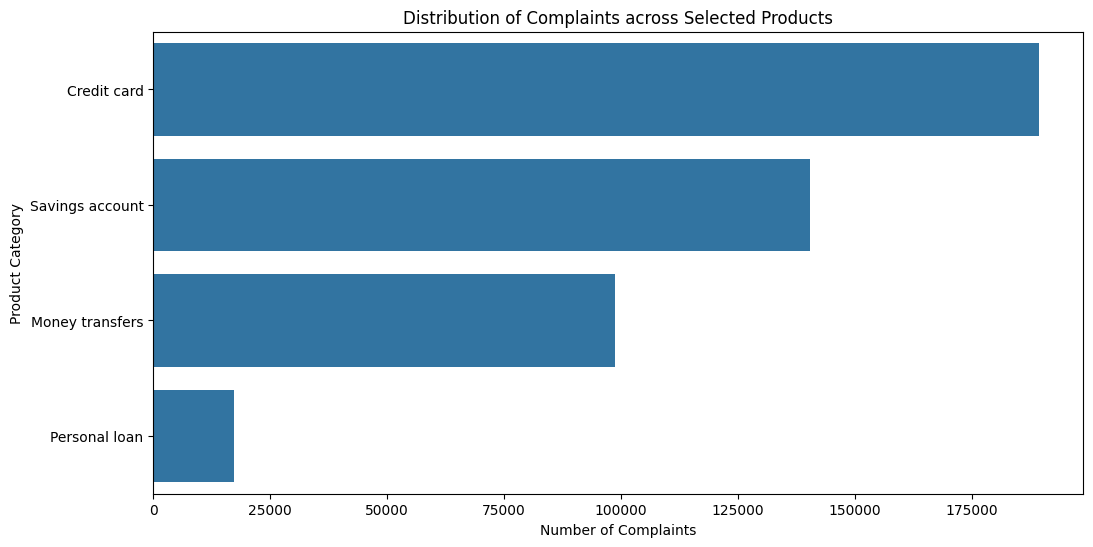

In [3]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_cleaned, y='Product_Group', order=df_cleaned['Product_Group'].value_counts().index)
plt.title('Distribution of Complaints across Selected Products')
plt.xlabel('Number of Complaints')
plt.ylabel('Product Category')
plt.show()

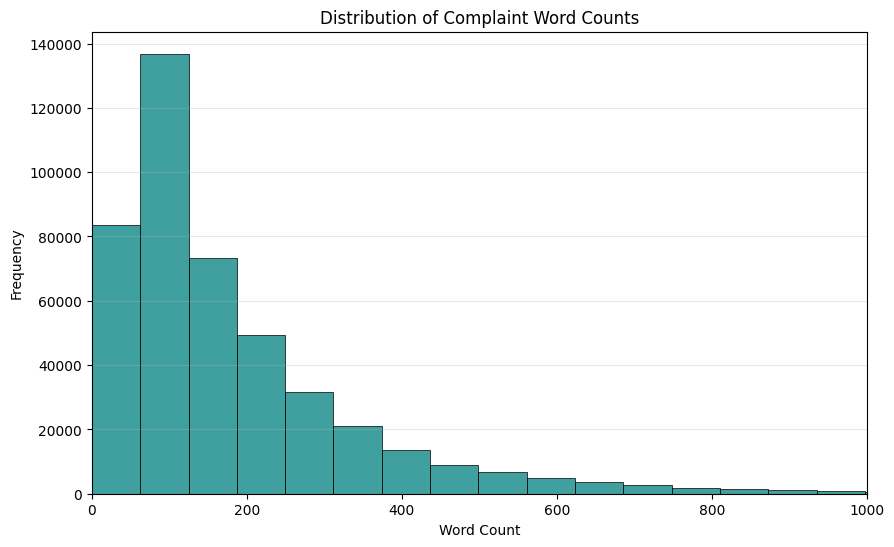

Average word count: 190.14
Max word count: 6234


In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['word_count'], bins=100, color='teal')
plt.xlim(0, 1000) # Limiting x-axis to see the bulk of the data
plt.title('Distribution of Complaint Word Counts')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Average word count: {df_cleaned['word_count'].mean():.2f}")
print(f"Max word count: {df_cleaned['word_count'].max()}")

In [5]:
# This will sample 15,000 records, chunk them, and save the FAISS index
create_vector_store(PROCESSED_DATA, VECTOR_STORE_DIR)

Performing stratified sampling...
Created 41087 chunks from 15000 documents.


/Users/mac/Documents/kaim/rag-complaint-chatbot/src/indexing.py:54: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")


Generating embeddings and building FAISS index...
Vector store persisted to ../vector_store/faiss_index
